# Denoising in the Wavelet Domain


# Importing Libraries


In [33]:
import numpy as np
import os
import matplotlib.pyplot as plt
from PIL import Image
import pywt

# Main


## Image loading


In [34]:
DATA_FOLDER_PATH = "../Data" #Specify Data folder directory here
FILENAME = "barbara.jpg" #Specify file name here


filepath = os.path.join(DATA_FOLDER_PATH, FILENAME)

In [35]:
image = Image.open(filepath).convert('L') #Load image as a grayscale
image = np.array(image).astype(np.float32) #Convert Image to array

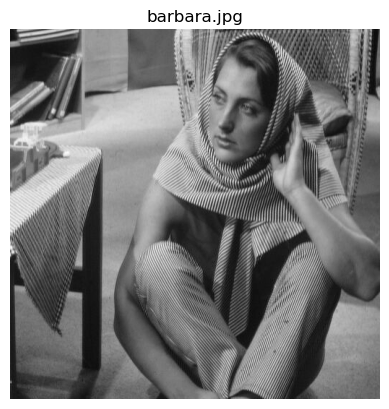

In [36]:
##Display loaded image

plt.imshow(image, cmap='gray')
plt.axis('off')
plt.title(FILENAME)
plt.show()

## Noisy Image


In [37]:
snr_db = 10

signalPower = np.mean(image**2)
noisePower = signalPower / (10 ** (snr_db / 10))

noise = np.random.normal(0, np.sqrt(noisePower), image.shape)

noisyImage = np.clip(image + noise, 0, 255)

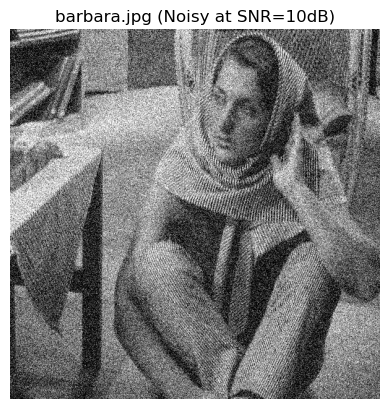

In [38]:
##Display loaded image

plt.imshow(noisyImage, cmap='gray')
plt.axis('off')
plt.title(FILENAME + f" (Noisy at SNR={snr_db}dB)")
plt.show()

## Denoising


### Hard thresholding


In [39]:
# Parameters
wavelet = 'db1'
level = 2

In [40]:
coeffs = pywt.wavedec2(noisyImage, wavelet=wavelet, level=level)

In [41]:
# Thresholding coefficients
sigma = np.median(np.abs(coeffs[-1][-1])) / 0.6745
threshold = sigma * np.sqrt(2 * np.log(image.size)) # Universal threshold, by estimating noise from last-level coefficient in the wavelet domain

#threshold = 50 #Uncomment this line for manually specifying threshold

In [42]:
new_coeffs = [coeffs[0]]
for details in coeffs[1:]:
    new_details = tuple(np.where(np.abs(d) > threshold, d, 0) for d in details)
    new_coeffs.append(new_details)

In [43]:
#Denoising
denoised_image = np.clip(pywt.waverec2(new_coeffs, wavelet=wavelet), 0, 255).astype(np.uint8)

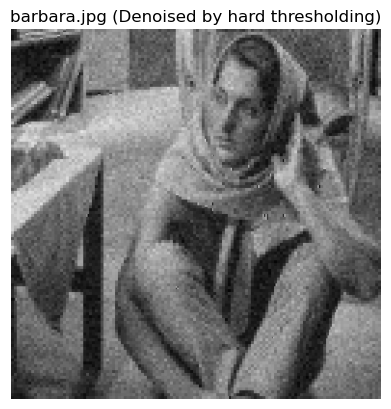

In [44]:
##Display denoised image

plt.imshow(denoised_image, cmap='gray')
plt.axis('off')
plt.title(FILENAME + f" (Denoised by hard thresholding)")
plt.show()

### Soft thresholding


In [45]:
# Soft thresholding, using same parameters as hard threhsolding

new_coeffs_soft = [coeffs[0]]
for details in coeffs[1:]:
    new_details = tuple(np.sign(d) * np.maximum(np.abs(d) - threshold, 0) for d in details)
    new_coeffs_soft.append(new_details)

In [46]:
# Denoising

denoised_image_soft = np.clip(pywt.waverec2(new_coeffs_soft, wavelet=wavelet), 0, 255).astype(np.uint8)

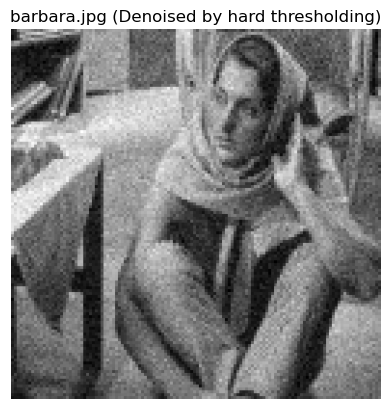

In [47]:
##Display denoised image

plt.imshow(denoised_image_soft, cmap='gray')
plt.axis('off')
plt.title(FILENAME + f" (Denoised by hard thresholding)")
plt.show()

## Results and discussion


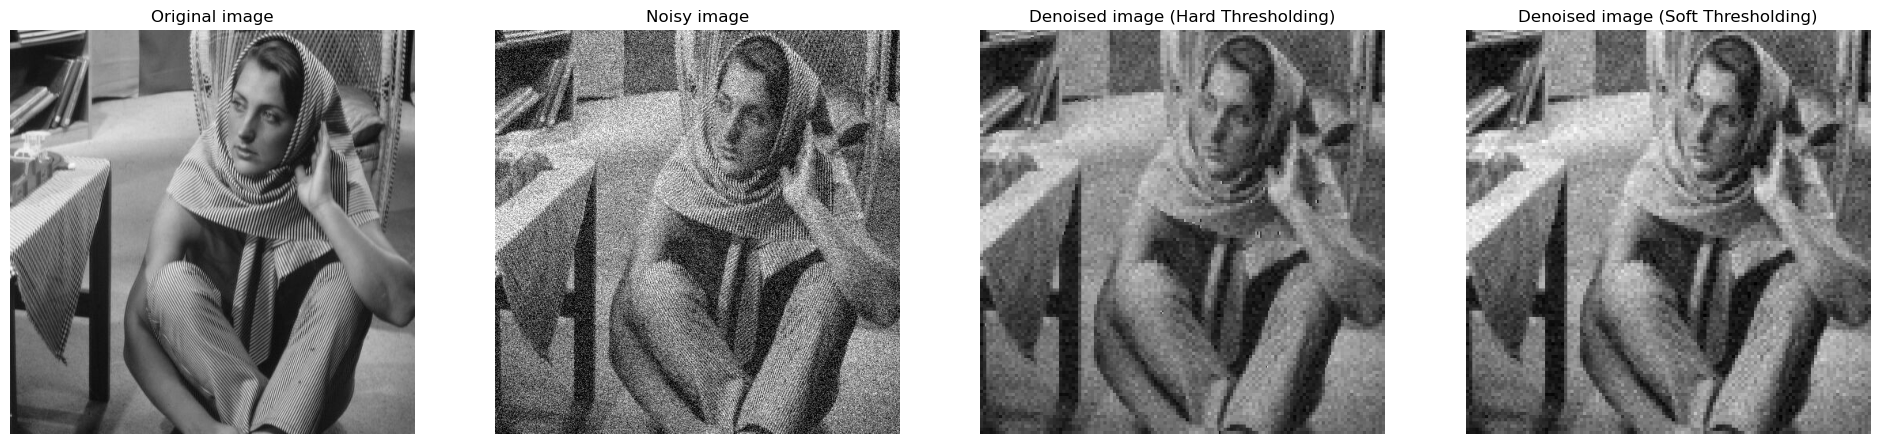

In [48]:
plt.figure(figsize=(24,12))

plt.subplot(1, 4, 1)
plt.imshow(image, cmap='gray')
plt.title("Original image")
plt.axis("off")

plt.subplot(1, 4, 2)
plt.imshow(noisyImage, cmap='gray')
plt.title("Noisy image")
plt.axis("off")

plt.subplot(1, 4, 3)
plt.imshow(denoised_image, cmap='gray')
plt.title("Denoised image (Hard Thresholding)")
plt.axis("off")

plt.subplot(1, 4, 4)
plt.imshow(denoised_image_soft, cmap='gray')
plt.title("Denoised image (Soft Thresholding)")
plt.axis("off")

plt.show()